In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings

warnings.filterwarnings('ignore')
cust_df = pd.read_csv('train.csv')
print('dataset shape:', cust_df.shape)
cust_df.head(3)

dataset shape: (76020, 371)


,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.17,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.03,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.77,0


In [5]:
cust_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76020 entries, 0 to 76019
Columns: 371 entries, ID to TARGET
dtypes: float64(111), int64(260)
memory usage: 215.2 MB


In [7]:
print(cust_df['TARGET'].value_counts())
unsatisfied_cnt = cust_df[cust_df['TARGET'] == 1 ].TARGET.count()
total_cnt = cust_df.TARGET.count()
print('unsatisfied 비율은 {0:.2f}'.format((unsatisfied_cnt / total_cnt)))

TARGET
0    73012
1     3008
Name: count, dtype: int64
unsatisfied 비율은 0.04


In [8]:
cust_df.describe

<bound method NDFrame.describe of            ID  var3  var15  imp_ent_var16_ult1  imp_op_var39_comer_ult1  \
0           1     2     23                 0.0                      0.0   
1           3     2     34                 0.0                      0.0   
2           4     2     23                 0.0                      0.0   
3           8     2     37                 0.0                    195.0   
4          10     2     39                 0.0                      0.0   
...       ...   ...    ...                 ...                      ...   
76015  151829     2     48                 0.0                      0.0   
76016  151830     2     39                 0.0                      0.0   
76017  151835     2     23                 0.0                      0.0   
76018  151836     2     25                 0.0                      0.0   
76019  151838     2     46                 0.0                      0.0   

       imp_op_var39_comer_ult3  imp_op_var40_comer_ult1  \
0                          0.0                      0.0   
1                          0.0                      0.0   
2                          0.0                      0.0   
3                        195.0                      0.0   
4                          0.0                      0.0   
...                        ...                      ...   
76015                      0.0                      0.0   
76016                      0.0                      0.0   
76017                      0.0                      0.0   
76018                      0.0                      0.0   
76019                      0.0                      0.0   

       imp_op_var40_comer_ult3  imp_op_var40_efect_ult1  \
0                          0.0                      0.0   
1                          0.0                      0.0   
2                          0.0                      0.0   
3                          0.0                      0.0   
4                          0.0                      0.0   
...                        ...                      ...   
76015                      0.0                      0.0   
76016                      0.0                      0.0   
76017                      0.0                      0.0   
76018                      0.0                      0.0   
76019                      0.0                      0.0   

       imp_op_var40_efect_ult3  ...  saldo_medio_var33_hace2  \
0                          0.0  ...                      0.0   
1                          0.0  ...                      0.0   
2                          0.0  ...                      0.0   
3                          0.0  ...                      0.0   
4                          0.0  ...                      0.0   
...                        ...  ...                      ...   
76015                      0.0  ...                      0.0   
76016                      0.0  ...                      0.0   
76017                      0.0  ...                      0.0   
76018                      0.0  ...                      0.0   
76019                      0.0  ...                      0.0   

       saldo_medio_var33_hace3  saldo_medio_var33_ult1  \
0                          0.0                     0.0   
1                          0.0                     0.0   
2                          0.0                     0.0   
3                          0.0                     0.0   
4                          0.0                     0.0   
...                        ...                     ...   
76015                      0.0                     0.0   
76016                      0.0                     0.0   
76017                      0.0                     0.0   
76018                      0.0                     0.0   
76019                      0.0                     0.0   

       saldo_medio_var33_ult3  saldo_medio_var44_hace2  \
0                         0.0                      0.0   
1                         0.0                      0.0   
2      

In [13]:
cust_df['var3'].replace(-999999, 2, inplace=True)
cust_df.drop('ID', axis=1, inplace=True, errors='ignore')

X_features = cust_df.iloc[:,:-1]
y_lables = cust_df.iloc[:,-1]
print('피처 데이터 shape: {0}'.format(X_features.shape))

피처 데이터 shape: (76020, 369)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_features, y_lables, test_size=0.2, random_state=0)

train_cnt = y_train.count()
test_cnt = y_test.count()
print('학습 세트 Shape:{0}, 테스트 세트 Shape:{1}'.format(X_train.shape, X_test.shape))
print('학습 세트 레이블 값 분포 비율')
print(y_train.value_counts()/train_cnt)
print('\n 테스트 세트 레이블 값 분포 비율')
print(y_test.value_counts()/test_cnt)

학습 세트 Shape:(60816, 369), 테스트 세트 Shape:(15204, 369)
학습 세트 레이블 값 분포 비율
TARGET
0    0.960964
1    0.039036
Name: count, dtype: float64

 테스트 세트 레이블 값 분포 비율
TARGET
0    0.9583
1    0.0417
Name: count, dtype: float64


In [16]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train,test_size=0.3,random_state=0 )

In [22]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

xgb_clf = XGBClassifier(
    n_estimators=500,
    random_state=156,
    eval_metric="auc",
    early_stopping_rounds=100
)

xgb_clf.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=False
)

xgb_roc_score = roc_auc_score(
    y_test,
    xgb_clf.predict_proba(X_test)[:, 1]
)

print('ROC AUC: {0:.4f}'.format(xgb_roc_score))

ROC AUC: 0.8377


In [23]:
from hyperopt import hp

xgb_search_space = {
    'max_depth': hp.quniform('max_depth', 5, 15, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1,6,1),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 0.95),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2)
}

In [38]:
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score

def objective_func(search_space):
    roc_auc_scores = []
    kf = KFold(n_splits=5)

    for tr_index, val_index in kf.split(X_train):
        X_tr, y_tr = X_train.iloc[tr_index], y_train.iloc[tr_index]
        X_val, y_val = X_train.iloc[val_index], y_train.iloc[val_index]

        xgb_clf = XGBClassifier(
            n_estimators=100,
            max_depth=int(search_space['max_depth']),
            min_child_weight=int(search_space['min_child_weight']),
            colsample_bytree=search_space['colsample_bytree'],
            learning_rate=search_space['learning_rate'],
            eval_metric="auc",
            early_stopping_rounds=30
        )

        xgb_clf.fit(
            X_tr,
            y_tr,
            eval_set=[(X_tr, y_tr), (X_val, y_val)],
            verbose=False
        )

        score = roc_auc_score(
            y_val,
            xgb_clf.predict_proba(X_val)[:, 1]
        )

        roc_auc_scores.append(score)

    return -1 * np.mean(roc_auc_scores)

In [39]:
from hyperopt import fmin, tpe, Trials

trials = Trials()

best = fmin(
    fn=objective_func,
    space=xgb_search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(30)
)

print('best:', best)

100%|██████████| 50/50 [33:37<00:00, 40.35s/trial, best loss: -0.8399872099387011]
best: {'colsample_bytree': np.float64(0.6848964687546426), 'learning_rate': np.float64(0.0709453695953271), 'max_depth': np.float64(6.0), 'min_child_weight': np.float64(5.0)}


In [42]:
xgb_clf = XGBClassifier(
    n_estimators=500,
    learning_rate=round(best['learning_rate'], 5),
    max_depth=int(best['max_depth']),
    min_child_weight=int(best['min_child_weight']),
    colsample_bytree=round(best['colsample_bytree'], 5),
    eval_metric="auc",
    early_stopping_rounds=100
)

xgb_clf.fit(
    X_tr,
    y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)]
)

xgb_roc_score = roc_auc_score(
    y_test,
    xgb_clf.predict_proba(X_test)[:, 1]
)

print('ROC AUC: {0:.4f}'.format(xgb_roc_score))

[0]	validation_0-auc:0.83942	validation_1-auc:0.81556
[1]	validation_0-auc:0.83729	validation_1-auc:0.81177
[2]	validation_0-auc:0.84671	validation_1-auc:0.82311
[3]	validation_0-auc:0.85213	validation_1-auc:0.82751
[4]	validation_0-auc:0.85389	validation_1-auc:0.82882
[5]	validation_0-auc:0.85527	validation_1-auc:0.82937
[6]	validation_0-auc:0.85593	validation_1-auc:0.82997
[7]	validation_0-auc:0.85728	validation_1-auc:0.83087
[8]	validation_0-auc:0.85900	validation_1-auc:0.83120
[9]	validation_0-auc:0.85984	validation_1-auc:0.83070
[10]	validation_0-auc:0.86154	validation_1-auc:0.83191
[11]	validation_0-auc:0.86262	validation_1-auc:0.83172
[12]	validation_0-auc:0.86368	validation_1-auc:0.83261
[13]	validation_0-auc:0.86441	validation_1-auc:0.83347
[14]	validation_0-auc:0.86550	validation_1-auc:0.83366
[15]	validation_0-auc:0.86635	validation_1-auc:0.83376
[16]	validation_0-auc:0.86715	validation_1-auc:0.83392
[17]	validation_0-auc:0.86775	validation_1-auc:0.83380
[18]	validation_0-au

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

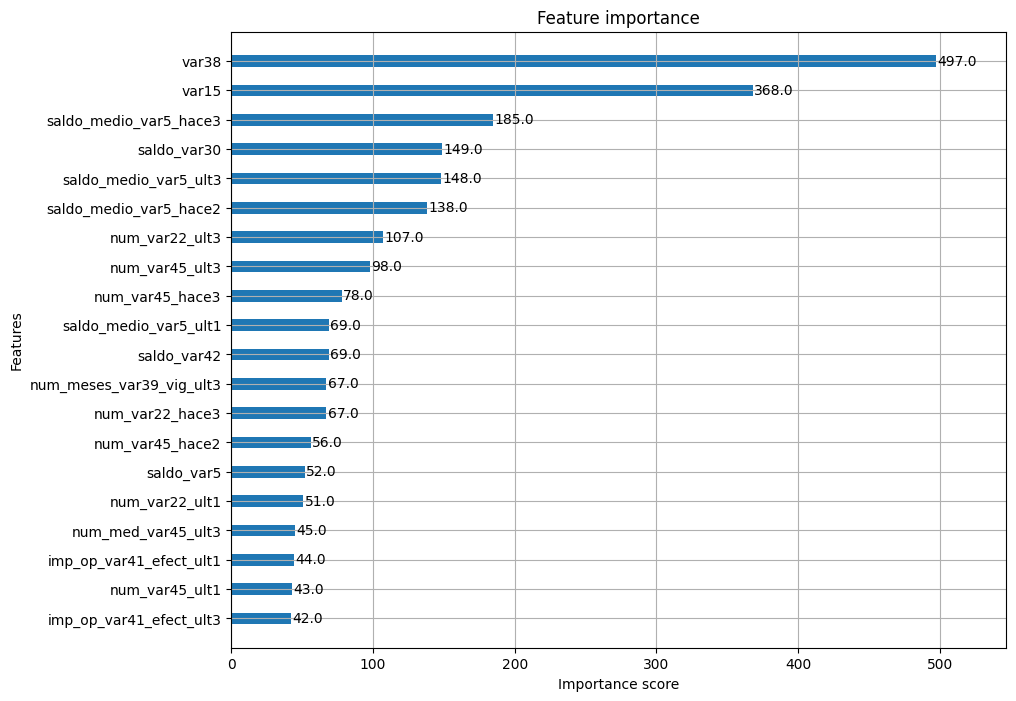

In [43]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(1,1,figsize=(10,8))
plot_importance(xgb_clf, ax=ax, max_num_features=20, height=0.4)


In [46]:
import lightgbm as lgb
from lightgbm import LGBMClassifier

lgbm_clf = LGBMClassifier(n_estimators=500)

eval_set = [(X_tr, y_tr), (X_val, y_val)]

lgbm_clf.fit(
    X_tr,
    y_tr,
    eval_metric="auc",
    eval_set=eval_set,
    callbacks=[lgb.early_stopping(100)]
)

lgbm_roc_score = roc_auc_score(
    y_test,
    lgbm_clf.predict_proba(X_test)[:, 1]
)

print('ROC AUC: {0:.4f}'.format(lgbm_roc_score))

[LightGBM] [Info] Number of positive: 1658, number of negative: 40913
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.096880 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13308
[LightGBM] [Info] Number of data points in the train set: 42571, number of used features: 242
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.038947 -> initscore=-3.205836
[LightGBM] [Info] Start training from score -3.205836
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[42]	training's auc: 0.91059	training's binary_logloss: 0.112183	valid_1's auc: 0.831787	valid_1's binary_logloss: 0.13527
ROC AUC: 0.8384


In [47]:
lgbm_search_space = {'num_leaves':hp.quniform('num_leaves',32,64,1),
                     'max_depth':hp.quniform('max_depth',100,160,1),
                     'min_child_samples':hp.quniform('min_child_samples',60,100,1),
                     'subsample':hp.uniform('subsample',0.7,1),
                     'learning_rate':hp.uniform('learning_rate',0.01,0.2)
                     }

In [65]:
import lightgbm as lgb

def objective_func(search_space):
    lgbm_clf = LGBMClassifier(
        n_estimators=100,
        num_leaves=int(search_space['num_leaves']),
        max_depth=int(search_space['max_depth']),
        min_child_samples=int(search_space['min_child_samples']),
        subsample=search_space['subsample'],
        learning_rate=search_space['learning_rate']
    )

    roc_auc_list = []

    kf = KFold(n_splits=3)

    for tr_index, val_index in kf.split(X_train):
        X_tr, y_tr = X_train.iloc[tr_index], y_train.iloc[tr_index]
        X_val, y_val = X_train.iloc[val_index], y_train.iloc[val_index]

        lgbm_clf.fit(
            X_tr,
            y_tr,
            eval_metric="auc",
            eval_set=[(X_tr, y_tr), (X_val, y_val)],
            callbacks=[lgb.early_stopping(100, verbose=False)]
        )

        score = roc_auc_score(
            y_val,
            lgbm_clf.predict_proba(X_val)[:, 1]
        )

        roc_auc_list.append(score)

    return -1 * np.mean(roc_auc_list)

In [66]:
from hyperopt import fmin, tpe, Trials

trials = Trials()
best = fmin(fn=objective_func,
            space=lgbm_search_space,
            algo=tpe.suggest,
            max_evals=50,
            trials=trials,
            rstate=np.random.default_rng(seed=30))

print('best:',best)

[LightGBM] [Info] Number of positive: 1579, number of negative: 38965
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048942 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12827
[LightGBM] [Info] Number of data points in the train set: 40544, number of used features: 192
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.038945 -> initscore=-3.205872
[LightGBM] [Info] Start training from score -3.205872
[LightGBM] [Info] Number of positive: 1609, number of negative: 38935
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.049781 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13008
[LightGBM] [Info] Number of data points in the train set: 40544, number of used features: 197
[LightGBM] [Info

In [68]:
import lightgbm as lgb

lgbm_clf = LGBMClassifier(
    n_estimators=500,
    num_leaves=int(best['num_leaves']),
    max_depth=int(best['max_depth']),
    min_child_samples=int(best['min_child_samples']),
    subsample=round(best['subsample'], 5),
    learning_rate=round(best['learning_rate'], 5)
)

lgbm_clf.fit(
    X_tr,
    y_tr,
    eval_metric="auc",
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    callbacks=[lgb.early_stopping(100, verbose=False)]
)

lgbm_roc_score = roc_auc_score(
    y_test,
    lgbm_clf.predict_proba(X_test)[:, 1]
)

print('ROC AUC: {0:.4f}'.format(lgbm_roc_score))

[LightGBM] [Info] Number of positive: 1658, number of negative: 40913
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.077944 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13001
[LightGBM] [Info] Number of data points in the train set: 42571, number of used features: 202
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.038947 -> initscore=-3.205836
[LightGBM] [Info] Start training from score -3.205836
ROC AUC: 0.8423
